In [173]:
"""Initialization of sites, MPS and MPO."""

import tenpy
from tenpy.networks.mpo import MPO
from tenpy.networks.mps import MPS
from tenpy.networks.site import SpinSite
from tenpy.models.model import MPOModel
import numpy as np
import tenpy.linalg.np_conserved as npc


In [174]:
def build_inf_T_MPS(N, chi):
    spin = SpinSite(S=1.5, conserve='None') # 4-level local Hilbert space

    sites = [spin] * N  # repeat entry of list N times

    M_L = np.zeros((4, 1, chi))
    M_L[:,0,0] = np.array([[1, 0, 0, 1]])
    M_R = np.zeros((4, chi, 1))
    M_R[:,0,0] = np.array([[1, 0, 0, 1]])
    M = np.zeros((4,chi,chi))
    M[:, 0, 0] = np.array([1, 0, 0, 1])
    Ms = [M for _ in range(N-2)]
    tensor_list = [M_L] + Ms + [M_R]

    psi = MPS.from_Bflat(sites, tensor_list, bc='finite', unit_cell_width=N)
    return psi

In [175]:
# define an MPO
def build_thf_model(N, J=1.0, h=0.25, g=-0.525):
    spin = SpinSite(S=1.5, conserve='None')
    x, z = np.array([[0,1], [1,0]]), np.array([[1,0], [0,-1]])

    Id = npc.Array.from_ndarray_trivial(np.eye(4), labels=['p', 'p*'])
    H1 = npc.Array.from_ndarray_trivial(np.kron(z, np.eye(2)),labels=['p', 'p*'])
    H2 = npc.Array.from_ndarray_trivial(np.kron(np.eye(2), z),labels=['p', 'p*'])
    hx = npc.Array.from_ndarray_trivial(np.kron(x, np.eye(2)) + np.kron(np.eye(2), x),
                                        labels=['p', 'p*'])
    hz = npc.Array.from_ndarray_trivial(np.kron(z, np.eye(2)) + np.kron(np.eye(2), z),
                                        labels=['p', 'p*'])
    W_bulk = [
        [Id,    H1,     H2,     g*hx+h*hz],
        [None,  None,   None,   J*H2],
        [None,  None,   None,   J*H1],
        [None,  None,   None,   Id],
    ]
    W_first = [W_bulk[0]]  # first row
    W_last = [[row[-1]] for row in W_bulk]  # last column
    Ws = [W_first] + [W_bulk] * (N - 2) + [W_last]
    H_MPO = MPO.from_grids([spin] * N, Ws, bc='finite', IdL=0, IdR=-1, mps_unit_cell_width=N)
    lattice = tenpy.models.lattice.Chain(N, spin)
    return MPOModel(lattice, H_MPO)

    

In [176]:
from tenpy.algorithms import tdvp
# check for consistency with my own code
N = 8  # number of sites
chi = 16 # bond dimension
final_beta = 0.01
N_steps = 10
delta_beta = final_beta / N_steps

psi = build_inf_T_MPS(N, chi=16)

thf_model = build_thf_model(N)

tdvp_params = {
        'start_time': 0,
        'dt': -1j*delta_beta/4,
        'N_steps': 1,
        'trunc_params': {'chi_max': chi, 'svd_min': 1.0e-10, 'trunc_cut': None},
    }
tdvp_engine = tdvp.TwoSiteTDVPEngine(psi, thf_model, tdvp_params)
times = []
S_mid = []
Es = []

def measure():
    print('Chi: ', psi.chi)
    times.append(tdvp_engine.evolved_time)
    S_mid.append(psi.entanglement_entropy(bonds=[N // 2])[0])
    Es.append(thf_model.H_MPO.expectation_value(psi))

   

In [177]:

measure()
for i in range(N_steps):
    tdvp_engine.run()
    measure()


Chi:  [1, 1, 1, 1, 1, 1, 1]


c:\Users\osolomonstuke\AppData\Local\anaconda3\Lib\site-packages\tenpy\algorithms\algorithm.py:401: UserWarning: Invalid type for key "dt". Expected <class 'numbers.Real'>. Got complex.
  dt = self.options.get('dt', 0.1, 'real')


Chi:  [2, 2, 2, 2, 2, 2, 2]


c:\Users\osolomonstuke\AppData\Local\anaconda3\Lib\site-packages\tenpy\algorithms\algorithm.py:401: UserWarning: Invalid type for key "dt". Expected <class 'numbers.Real'>. Got complex.
  dt = self.options.get('dt', 0.1, 'real')


Chi:  [2, 2, 2, 2, 2, 2, 2]


...

c:\Users\osolomonstuke\AppData\Local\anaconda3\Lib\site-packages\tenpy\algorithms\algorithm.py:401: UserWarning: Invalid type for key "dt". Expected <class 'numbers.Real'>. Got complex.
  dt = self.options.get('dt', 0.1, 'real')


Chi:  [3, 3, 3, 3, 3, 3, 3]


c:\Users\osolomonstuke\AppData\Local\anaconda3\Lib\site-packages\tenpy\algorithms\algorithm.py:401: UserWarning: Invalid type for key "dt". Expected <class 'numbers.Real'>. Got complex.
  dt = self.options.get('dt', 0.1, 'real')


Chi:  [3, 3, 3, 3, 3, 3, 3]
Chi:  [3, 3, 3, 3, 3, 3, 3]


c:\Users\osolomonstuke\AppData\Local\anaconda3\Lib\site-packages\tenpy\algorithms\algorithm.py:401: UserWarning: Invalid type for key "dt". Expected <class 'numbers.Real'>. Got complex.
  dt = self.options.get('dt', 0.1, 'real')


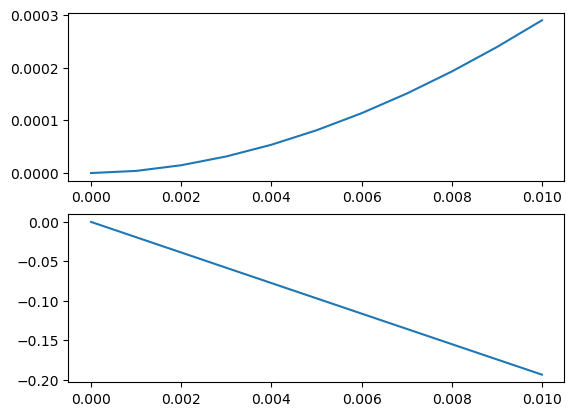

In [178]:
import matplotlib.pyplot as plt
times = np.linspace(0, final_beta, N_steps+1)
fig, ax = plt.subplots(2,1)
ax[0].plot(times, S_mid)
ax[1].plot(times, Es)

In [172]:
print("Final E and S: ", Es[-1]/2, S_mid[-1])

Final E and S:  -0.0969150361863822 0.0002898952205979027


In [150]:
print("Final E and S: ", Es[-1], S_mid[-1])

Final E and S:  0.7801273702154522 0.00352560005605253


In [156]:
print("Final E and S: ", Es[-1], S_mid[-1])

Final E and S:  0.7801273694727555 0.0035256000553103716


101